# 🎬 Movie Recommendation System
**CV Project #2** | Skills: Collaborative Filtering, Content-Based Filtering, Cosine Similarity, Matrix Factorization

## 📖 Introduction

Have you ever wondered how Netflix knows exactly what to suggest next, or how Spotify keeps serving up songs you love? The secret is a **Recommendation System** — one of the most widely used and impactful applications of machine learning in the real world.

In this project, we build a **Movie Recommendation System** from scratch using three complementary techniques:

- **Content-Based Filtering** — recommends movies similar to ones you already like, based on their genres and descriptions.
- **Collaborative Filtering** — finds users with similar tastes and recommends what they enjoyed.
- **Matrix Factorization (SVD)** — decomposes the user-movie rating matrix to uncover hidden patterns and predict unseen ratings.
- **Hybrid System** — combines content-based and collaborative scores for richer, more personalised recommendations.

We work with a synthetic dataset of **50 movies**, **200 users**, and ~**2,800 ratings**, carefully designed to mimic the sparsity and variability of real-world movie rating data.


## 🎯 Objectives

By the end of this project, we will have:

1. **Built and explored** a realistic synthetic movie-ratings dataset.
2. **Implemented content-based filtering** using TF-IDF vectorisation and cosine similarity on movie genres.
3. **Implemented collaborative filtering** using user-user similarity on a sparse ratings matrix.
4. **Trained an SVD matrix factorisation model** and evaluated it using RMSE and MAE on a held-out test set.
5. **Built a hybrid recommender** that blends content-based and collaborative signals with a tunable weight (alpha).
6. **Evaluated the system** with standard recommendation metrics (RMSE, MAE, Precision@K).

## 💡 What We Get Out of This

After running this notebook you will have:

| Output | Description |
|--------|-------------|
| `recommendation_eda.png` | 4-panel EDA dashboard (rating distribution, most-rated movies, ratings per user, genre frequency) |
| `svd_variance.png` | Chart showing cumulative explained variance by SVD components |
| Content-based recommendations | Top-N similar movies for any title in the dataset |
| Collaborative recommendations | Top-N personalised movies for any user ID |
| SVD predictions | RMSE and MAE scores measuring how accurately the model predicts unseen ratings |
| Hybrid recommendations | Blended recommendations combining both filtering methods |



---
## 🔧 Step Zero: Install Dependencies

In [1]:
# Install all required libraries quietly (-q suppresses verbose pip output).
# pandas    → data manipulation and DataFrames
# numpy     → numerical computing and array operations
# scikit-learn → TF-IDF, cosine similarity, SVD, train/test split, metrics
# matplotlib → static visualisations
# seaborn   → statistical plots built on top of matplotlib
# scipy     → sparse matrix support (CSR format for efficient user-item matrix)
!pip install pandas numpy scikit-learn matplotlib seaborn scipy -q

---
## 📦 Step 1: Build the Movie & Ratings Dataset

We generate a synthetic dataset that mirrors the structure of a real-world movie platform:
- A **movies table** with 50 well-known titles, their genres, release year, and an average rating.
- A **ratings table** where 200 simulated users each rate 8–20 random movies.

Using synthetic data means we control every aspect of the data generation, making results fully reproducible.

In [2]:
# Core data libraries
import pandas as pd           # DataFrames: groupby, merge, pivot_table, etc.
import numpy as np            # Array math, random sampling, linear algebra

# Visualisation libraries 
import matplotlib.pyplot as plt   # Base plotting (histograms, bar charts, line charts)
import seaborn as sns             # Higher-level statistical plots

# Machine learning building blocks (from scikit-learn)
from sklearn.feature_extraction.text import TfidfVectorizer  # Text → TF-IDF matrix
from sklearn.metrics.pairwise import cosine_similarity        # Pairwise cosine similarity
from sklearn.decomposition import TruncatedSVD               # Matrix factorisation (SVD)

# Sparse matrix support 
# CSR (Compressed Sparse Row) is the standard format for storing large, mostly-zero
# matrices efficiently. Our user-item matrix will be ~72% zeros (sparse).
from scipy.sparse import csr_matrix

# Suppress non-critical warnings for cleaner notebook output
import warnings
warnings.filterwarnings('ignore')

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


In [3]:
# Fix the random seed so every run of this notebook produces identical results.
# This is essential for reproducibility — anyone cloning the repo should get
# the same dataset, the same splits, and the same evaluation metrics.
np.random.seed(42)

In [4]:
# Build the movies DataFrame 
# We include 50 well-known titles across a variety of genres.
# The 'genres' column is a space-separated string of genre tags —
# this format is what TF-IDF expects as input (a corpus of text documents).
#
# avg_rating: a randomly drawn 'true' average rating in [6.5, 9.3].
# We'll use this as the base for generating per-user ratings in the next cell.

movies = pd.DataFrame({
    'movie_id': range(1, 51),
    'title': [
        'The Dark Knight', 'Inception', 'Interstellar', 'The Matrix', 'Pulp Fiction',
        'The Godfather', 'Goodfellas', 'Schindlers List', 'The Shawshank Redemption', 'Forrest Gump',
        'Fight Club', 'The Silence of the Lambs', 'Se7en', 'The Departed', 'Whiplash',
        'La La Land', 'The Grand Budapest Hotel', 'Parasite', 'Spirited Away', 'Your Name',
        'Avengers Endgame', 'Iron Man', 'Captain America', 'Thor Ragnarok', 'Guardians of the Galaxy',
        'Toy Story', 'Finding Nemo', 'The Lion King', 'Shrek', 'Coco',
        'Get Out', 'A Quiet Place', 'Hereditary', 'The Conjuring', 'It',
        'Mad Max Fury Road', 'John Wick', 'Mission Impossible', 'Die Hard', 'Speed',
        'The Notebook', 'Titanic', 'Pride and Prejudice', 'Before Sunrise', 'Eternal Sunshine',
        'Blade Runner 2049', 'Ex Machina', 'Arrival', 'The Martian', 'Gravity'
    ],
    'genres': [
        # Each string is a 'bag of genre words' — TF-IDF treats each word as a feature.
        # Movies with many overlapping genre words will have high cosine similarity.
        'action crime drama thriller', 'action sci-fi thriller mystery', 'sci-fi drama adventure space',
        'action sci-fi thriller', 'crime drama thriller mystery',
        'crime drama thriller', 'crime drama thriller biography', 'drama history biography war',
        'drama', 'drama romance comedy',
        'drama thriller mystery', 'thriller crime horror mystery', 'crime drama thriller mystery',
        'crime drama thriller', 'drama music',
        'drama romance music comedy', 'comedy drama adventure', 'drama thriller',
        'animation fantasy adventure family', 'animation romance drama fantasy',
        'action sci-fi adventure fantasy', 'action sci-fi adventure', 'action sci-fi adventure',
        'action comedy sci-fi adventure', 'action comedy sci-fi adventure',
        'animation comedy adventure family', 'animation comedy adventure family',
        'animation drama family', 'animation comedy adventure family', 'animation drama family music',
        'horror thriller mystery', 'horror thriller sci-fi', 'horror drama mystery',
        'horror thriller mystery', 'horror thriller',
        'action sci-fi adventure', 'action thriller crime', 'action thriller',
        'action thriller comedy', 'action thriller',
        'romance drama', 'romance drama history', 'romance drama comedy',
        'romance drama', 'romance drama sci-fi',
        'sci-fi drama thriller mystery', 'sci-fi drama thriller mystery',
        'sci-fi drama mystery', 'sci-fi adventure comedy drama', 'sci-fi thriller drama'
    ],
    # Random release years between 1990 and 2023
    'year': np.random.choice(range(1990, 2024), 50),
    # Random average rating in [6.5, 9.3] rounded to 1 decimal place
    'avg_rating': np.round(np.random.uniform(6.5, 9.3, 50), 1)
})

print(f'Movie catalogue: {len(movies)} titles')
movies.head()

Movie catalogue: 50 titles


,movie_id,title,genres,year,avg_rating
0,1,The Dark Knight,action crime drama thriller,2018,7.6
1,2,Inception,action sci-fi thriller mystery,2004,9.1
2,3,Interstellar,sci-fi drama adventure space,1997,8.5
3,4,The Matrix,action sci-fi thriller,2010,7.4
4,5,Pulp Fiction,crime drama thriller mystery,2008,8.1


In [23]:
# Simulate user ratings 
# Real-world rating datasets are sparse: most users rate only a small fraction
# of all available movies. We replicate this by having each user rate only
# 8–20 randomly selected movies (out of 50).
#
# Each individual rating is generated by:
#   1. Starting with the movie's average rating (its 'true quality')
#   2. Adding Gaussian noise (mean=0, std=0.8) — simulating personal taste
#   3. Clipping to [1, 10] so no rating goes out of range
#
# This produces a realistic distribution with most ratings clustered around
# each movie's true quality, but with natural user-to-user variability.

n_users = 200
ratings_list = []

for user_id in range(1, n_users + 1):
    # Each user rates a random number of movies (8 to 20)
    n_rated   = np.random.randint(8, 21)
    # Pick that many movie IDs at random, without replacement
    movie_ids = np.random.choice(movies['movie_id'], n_rated, replace=False)

    for mid in movie_ids:
        # Look up the movie's base average rating
        base   = movies[movies['movie_id'] == mid]['avg_rating'].values[0]
        # Add personal taste noise, then clip to valid range
        rating = np.clip(base + np.random.normal(0, 0.8), 1, 10)
        ratings_list.append({
            'user_id':  user_id,
            'movie_id': int(mid),
            'rating':   round(rating, 1)
        })

ratings = pd.DataFrame(ratings_list)

# Sparsity check 
# Sparsity = fraction of (user, movie) pairs with NO rating.
# High sparsity is typical — Netflix's original dataset was ~99% sparse.
# Our synthetic dataset is ~72% sparse, which is realistic for a smaller platform.
sparsity = 1 - len(ratings) / (n_users * len(movies))

print(f'Movies: {len(movies)} | Users: {n_users} | Ratings: {len(ratings)}')
print(f'Sparsity: {sparsity:.2%}')   # How much of the matrix is empty
print(ratings.describe().round(2))

Movies: 50 | Users: 200 | Ratings: 2748
Sparsity: 72.52%
       user_id  movie_id   rating
count  2748.00   2748.00  2748.00
mean    100.55     25.88     7.94
std      57.21     14.31     1.09
min       1.00      1.00     3.80
25%      52.00     14.00     7.20
50%     100.00     26.00     8.00
75%     150.00     38.00     8.70
max     200.00     50.00    10.00


---
## 📊 Step 2: Exploratory Data Analysis

Before building any model it is crucial to understand the data visually.
We will answer four key questions:
1. How are ratings distributed? (Is it bell-shaped or skewed?)
2. Which movies have been rated the most?
3. How active are our users? (How many movies does a typical user rate?)
4. Which genres appear most frequently in the catalogue?

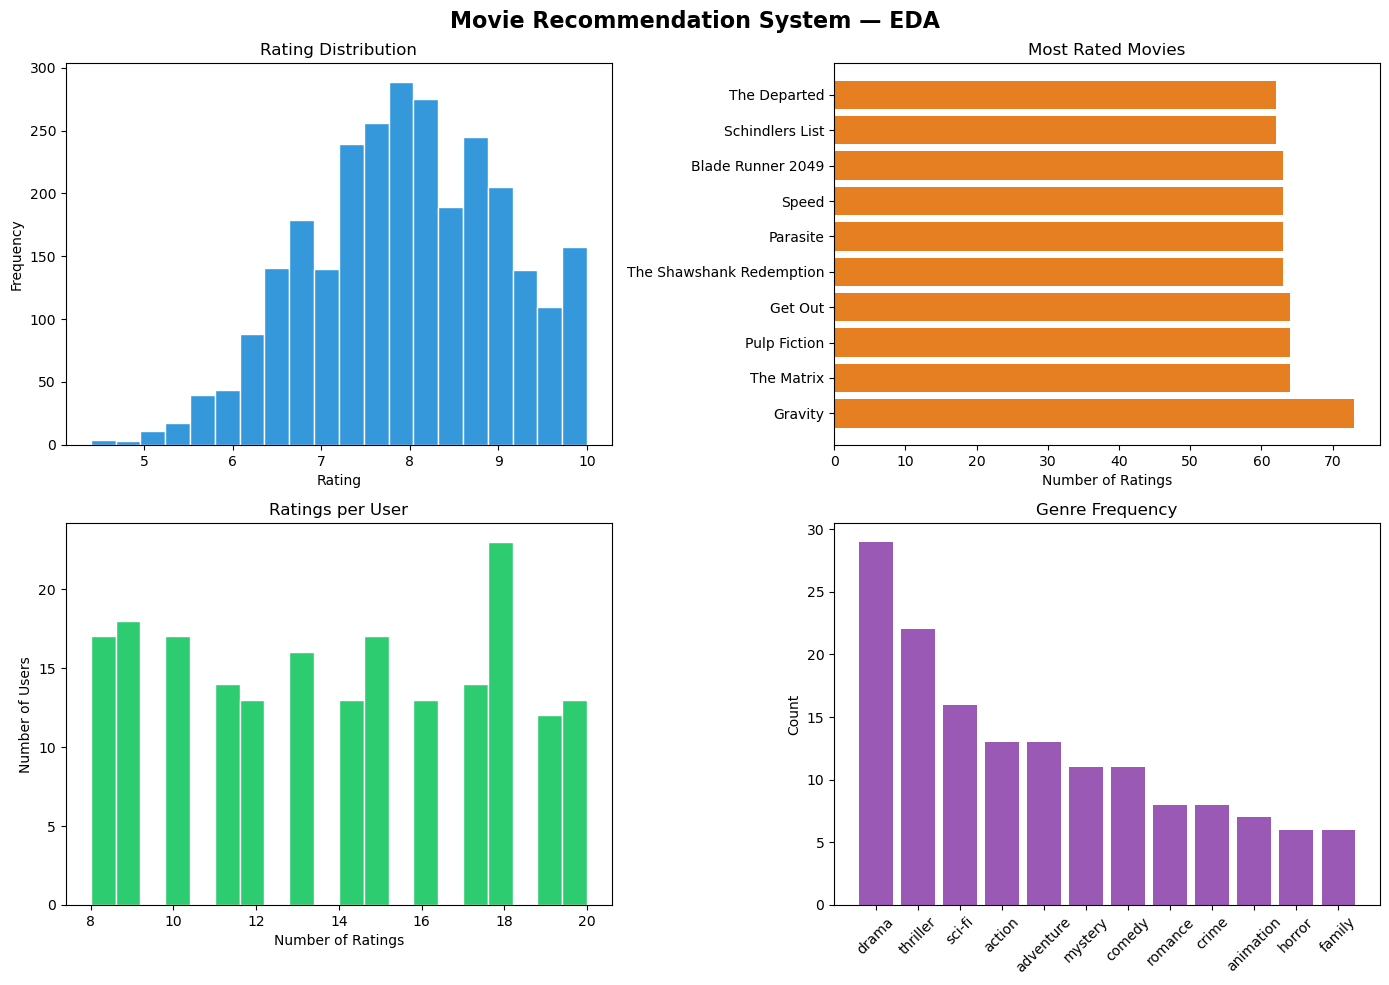

✅ EDA dashboard saved as recommendation_eda.png


In [6]:
# Create a 2x2 dashboard of EDA charts 
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Movie Recommendation System — EDA', fontsize=16, fontweight='bold')

# Panel 1: Rating Distribution
# WHAT: Histogram of all individual ratings in the dataset
# WHY:  Understanding the shape tells us about user behaviour.
#       A right-skewed distribution means users tend to rate movies they liked
#       (they skip movies they disliked), which is a well-known bias in rating data.
axes[0, 0].hist(ratings['rating'], bins=20, color='#3498db', edgecolor='white')
axes[0, 0].set_title('Rating Distribution')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Frequency')

# Panel 2: Most Rated Movies
# WHAT: Top 10 movies by number of user ratings
# WHY:  Popular movies have more ratings and therefore more reliable recommendations.
#       Less-rated movies suffer from the 'cold start' problem.
top_rated = ratings.groupby('movie_id').size().nlargest(10).reset_index()
top_rated = top_rated.merge(movies[['movie_id', 'title']], on='movie_id')
axes[0, 1].barh(
    top_rated['title'].str[:25],   # Truncate long titles to 25 chars for readability
    top_rated[0],
    color='#e67e22'
)
axes[0, 1].set_title('Most Rated Movies')
axes[0, 1].set_xlabel('Number of Ratings')

# Panel 3: Ratings per User
# WHAT: Histogram showing how many movies each user has rated
# WHY:  Users with very few ratings are hard to make recommendations for
#       (the 'cold start' problem for new users).
#       Users with many ratings produce richer collaborative signals.
user_counts = ratings.groupby('user_id').size()
axes[1, 0].hist(user_counts, bins=20, color='#2ecc71', edgecolor='white')
axes[1, 0].set_title('Ratings per User')
axes[1, 0].set_xlabel('Number of Ratings')
axes[1, 0].set_ylabel('Number of Users')

# Panel 4: Genre Frequency
# WHAT: Bar chart of the 12 most common genre words across all movies
# WHY:  Dominant genres will have more TF-IDF weight, shaping which movies
#       appear as 'similar' in content-based recommendations.
all_genres   = ' '.join(movies['genres']).split()    # Flatten all genre strings into one list
genre_counts = pd.Series(all_genres).value_counts().head(12)
axes[1, 1].bar(genre_counts.index, genre_counts.values, color='#9b59b6')
axes[1, 1].set_title('Genre Frequency')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('recommendation_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ EDA dashboard saved as recommendation_eda.png')


## 🔍 Step 3: Content-Based Filtering

**Idea:** 'If you liked *Inception*, you will probably enjoy other action/sci-fi/thriller movies.'

Content-based filtering recommends movies similar to a given title based purely on their **attributes** (in our case, genres), with no knowledge of what other users think.

**Algorithm:**
1. Represent each movie's genres as a **TF-IDF vector** (Term Frequency–Inverse Document Frequency).
   - TF-IDF downweights very common genre words (e.g. 'drama' appears everywhere) and upweights
     distinctive ones (e.g. 'biography') — capturing what really makes each movie unique.
2. Compute the **cosine similarity** between every pair of TF-IDF vectors.
   - Two movies with identical genre tags get similarity = 1.0.
   - Two movies with completely different genres get similarity around 0.0.
3. For any given movie, return the top-N most similar movies (excluding itself).

In [7]:
# Step 1: Build the TF-IDF matrix 
# TfidfVectorizer converts each genre string into a numeric vector.
# stop_words='english' removes common English words (not really needed here
# since genres are already short, but it is good practice).
tfidf     = TfidfVectorizer(stop_words='english')
tfidf_mat = tfidf.fit_transform(movies['genres'])
# tfidf_mat shape: (50 movies) x (number of unique genre words)

# Step 2: Compute pairwise cosine similarity
# cosine_similarity returns a 50x50 matrix.
# Entry [i][j] = cosine similarity between movie i and movie j.
# The diagonal is always 1.0 (every movie is identical to itself).
cosine_sim = cosine_similarity(tfidf_mat, tfidf_mat)

# Step 3: Build a title → index lookup 
# This lets us quickly find a movie's row index from its title string.
indices = pd.Series(movies.index, index=movies['title'])

print(f'TF-IDF matrix shape: {tfidf_mat.shape}  (movies x unique genre words)')
print(f'Cosine similarity matrix shape: {cosine_sim.shape}')

TF-IDF matrix shape: (50, 19)  (movies x unique genre words)
Cosine similarity matrix shape: (50, 50)


In [8]:
# Content-based recommendation function
def content_recommend(title, n=5):
    """
    Recommend the top-N movies most similar to `title` based on genre overlap.

    How it works:
      1. Look up the row index of the target movie.
      2. Extract cosine similarity scores for that row (vs. all other movies).
      3. Sort by similarity, descending.
      4. Skip the first result (the movie itself, similarity = 1.0).
      5. Return the next n results with their genre and similarity info.

    Parameters
    ----------
    title : str   The exact movie title (must match the 'title' column).
    n     : int   Number of recommendations to return (default 5).
    """
    if title not in indices:
        print(f'Movie "{title}" not found in catalogue!')
        return None

    idx    = indices[title]                               # Row index of the target movie
    scores = list(enumerate(cosine_sim[idx]))             # [(movie_idx, similarity), ...]
    scores = sorted(scores, key=lambda x: x[1], reverse=True)[1:n+1]  # Sort and skip self

    movie_indices = [i[0] for i in scores]                # Extract row indices
    result = movies.iloc[movie_indices][['title', 'genres', 'avg_rating']].copy()
    result['similarity'] = [round(s[1], 3) for s in scores]  # Attach similarity score
    return result

In [21]:
# Test the content-based recommender
# Inception is a sci-fi/thriller — expect other sci-fi/thrillers
print('Content-Based: Movies similar to "Inception"')
print(content_recommend('Inception').to_string(index=False))

print()

# Toy Story is an animated family film — expect other animation/family movies
print('Content-Based: Movies similar to "Toy Story"')
print(content_recommend('Toy Story').to_string(index=False))

Content-Based: Movies similar to "Inception"
            title                        genres  avg_rating  similarity
       The Matrix        action sci-fi thriller         7.4       0.862
Blade Runner 2049 sci-fi drama thriller mystery         6.8       0.828
       Ex Machina sci-fi drama thriller mystery         7.7       0.828
          Arrival          sci-fi drama mystery         7.1       0.741
         Iron Man       action sci-fi adventure         7.1       0.663

Content-Based: Movies similar to "Toy Story"
                   title                             genres  avg_rating  similarity
            Finding Nemo  animation comedy adventure family         8.3       1.000
                   Shrek  animation comedy adventure family         8.9       1.000
           The Lion King             animation drama family         9.1       0.728
           Spirited Away animation fantasy adventure family         7.6       0.710
The Grand Budapest Hotel             comedy drama adventu

---
## 🤝 Step 4: Collaborative Filtering (User-Item Matrix)

**Idea:** 'Users who liked the same movies as you will probably enjoy the same movies you have not seen yet.'

Collaborative filtering ignores movie content entirely and focuses only on **who rated what** and **how highly**. It exploits patterns in the crowd.

**Algorithm:**
1. Build a **user-item matrix** (rows = users, columns = movies, values = ratings).
   - Missing entries (movies a user has not rated) are filled with 0.
2. Compute **user-user cosine similarity** — how similar any two users' rating patterns are.
3. For a target user, find the 10 most similar users (their 'taste neighbours').
4. Recommend movies that the neighbours rated highly but the target user has not seen yet.

In [10]:
# Build the user-item rating matrix 
# pivot_table reshapes the long-format ratings DataFrame into a wide matrix:
#   Rows    = user IDs (200 users)
#   Columns = movie IDs (50 movies)
#   Values  = rating (NaN where the user has not rated that movie)
# .fillna(0) replaces all NaN entries with 0 (unrated = neutral)
user_item = ratings.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
).fillna(0)

# Convert to a CSR sparse matrix — this stores only the non-zero entries,
# which is much more memory-efficient when most entries are 0.
user_item_sparse = csr_matrix(user_item.values)

print(f'User-item matrix shape: {user_item.shape}  (users x movies)')
print(f'Non-zero entries: {user_item_sparse.nnz} / {user_item.shape[0] * user_item.shape[1]} total')

User-item matrix shape: (200, 50)  (users x movies)
Non-zero entries: 2771 / 10000 total


In [11]:
# Compute user-user cosine similarity
# Each user's row vector encodes their rating pattern across all 50 movies.
# Cosine similarity between two users = 1 if they rated exactly the same movies
# with exactly the same scores; close to 0 if their tastes are completely different.
user_sim    = cosine_similarity(user_item_sparse)           # 200x200 matrix
user_sim_df = pd.DataFrame(
    user_sim,
    index=user_item.index,     # Rows = user IDs
    columns=user_item.index    # Columns = user IDs
)

print(f'User similarity matrix shape: {user_sim_df.shape}')

User similarity matrix shape: (200, 200)


In [12]:
# Collaborative recommendation function 
def collab_recommend(user_id, n=5):
    """
    Recommend top-N movies for `user_id` using user-user collaborative filtering.

    How it works:
      1. Find the 10 most similar users (taste neighbours).
      2. Collect all movies rated by the neighbours.
      3. Exclude movies the target user has already rated.
      4. Score remaining candidates by their average rating among neighbours.
      5. Return the top-N highest-scoring candidates.

    Parameters
    ----------
    user_id : int   The ID of the user to make recommendations for.
    n       : int   Number of recommendations (default 5).
    """
    if user_id not in user_sim_df.index:
        print('User not found!')
        return None

    # Drop the user themselves from similarity ranking, then pick top 10
    similar_users = user_sim_df[user_id].drop(user_id).nlargest(10).index

    # Movies the target user has already rated — we must NOT recommend these
    rated_by_user   = set(ratings[ratings['user_id'] == user_id]['movie_id'])

    # Ratings from similar users, filtered to movies the target has not seen
    similar_ratings = ratings[ratings['user_id'].isin(similar_users)]
    candidates      = similar_ratings[~similar_ratings['movie_id'].isin(rated_by_user)]

    # Score each candidate movie by its mean rating among the similar users
    scores = candidates.groupby('movie_id')['rating'].mean().nlargest(n).reset_index()
    scores = scores.merge(movies[['movie_id', 'title', 'genres', 'avg_rating']], on='movie_id')
    scores.columns = ['movie_id', 'predicted_rating', 'title', 'genres', 'avg_rating']

    return scores[['title', 'genres', 'predicted_rating']]

In [22]:
# Test the collaborative recommender for User 1
# The output will vary by user — different users have different taste neighbours,
# so the recommendations are personalised.
print('Collaborative Filtering: Recommendations for User 1')
result = collab_recommend(1)
if result is not None:
    print(result.to_string(index=False))

Collaborative Filtering: Recommendations for User 1
                  title                            genres  predicted_rating
              Toy Story animation comedy adventure family              9.55
                  Shrek animation comedy adventure family              9.50
               Die Hard            action thriller comedy              9.30
Guardians of the Galaxy    action comedy sci-fi adventure              9.10
              Inception    action sci-fi thriller mystery              8.85



## 🔢 Step 5: SVD Matrix Factorisation

**Idea:** Decompose the user-item matrix into latent factors (hidden features like 'action-lover' or 'arthouse fan') and use them to predict missing ratings.

**Why SVD?**
- Plain collaborative filtering struggles with very sparse data. SVD fills in the gaps by learning low-dimensional representations of users and movies.
- It is the foundation of the algorithm that won the Netflix Prize in 2009.

**Algorithm:**
1. Split ratings into **train** (80%) and **test** (20%) sets.
2. Factorize the training matrix as **U x Sigma x Vt** (20 latent components).
3. Reconstruct the full matrix to get predicted ratings for all (user, movie) pairs.
4. Evaluate predictions on the test set using **RMSE** and **MAE**.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# Train / Test split 
# We hold out 20% of ratings for evaluation.
# random_state=42 ensures a consistent split every run.
train_df, test_df = train_test_split(ratings, test_size=0.2, random_state=42)

# Build the training matrix (same pivot_table → fillna(0) as before,
# but only using training ratings — the model must NOT see test ratings)
train_matrix = train_df.pivot_table(
    index='user_id',
    columns='movie_id',
    values='rating'
).fillna(0)

print(f'Training ratings: {len(train_df)} | Test ratings: {len(test_df)}')
print(f'Training matrix shape: {train_matrix.shape}')

Training ratings: 2216 | Test ratings: 555
Training matrix shape: (200, 50)


In [15]:
# Perform SVD decomposition
# TruncatedSVD keeps only the top k=20 singular values, which capture the most
# important patterns while discarding noise. This acts as regularisation.
#
# The decomposition: A ≈ U x Sigma x Vt
#   U     (users x 20)   — user latent factor matrix
#   Sigma (20 x 20)      — diagonal matrix of singular values
#   Vt    (20 x movies)  — movie latent factor matrix

svd   = TruncatedSVD(n_components=20, random_state=42)

# fit_transform computes U (the user factors). Sigma and Vt are stored inside svd.
U     = svd.fit_transform(csr_matrix(train_matrix.values))
Sigma = np.diag(svd.singular_values_)    # Diagonal matrix of singular values
Vt    = svd.components_                  # Movie latent factors (20 x n_movies)

# Reconstruct the full rating matrix: A_hat = U x Sigma x Vt
# Every cell now has a predicted rating, including for (user, movie) pairs
# that were empty (zeros) in the original training matrix.
reconstructed = np.dot(U, np.dot(Sigma, Vt))
pred_matrix   = pd.DataFrame(
    reconstructed,
    index=train_matrix.index,
    columns=train_matrix.columns
)

print(f'Reconstructed matrix shape: {pred_matrix.shape}')
print('SVD decomposition complete!')

Reconstructed matrix shape: (200, 50)
SVD decomposition complete!


In [16]:
# Evaluate on the test set
# For each test rating (user, movie, true_rating), we look up the model's
# predicted rating from the reconstructed matrix and collect the pair.
# We only evaluate on (user, movie) pairs that exist in the training matrix
# — some test users/movies may not have appeared in training.

actuals, preds = [], []

for _, row in test_df.iterrows():
    uid, mid = row['user_id'], row['movie_id']
    if uid in pred_matrix.index and mid in pred_matrix.columns:
        preds.append(pred_matrix.loc[uid, mid])    # Model prediction
        actuals.append(row['rating'])               # Ground truth

# RMSE: Root Mean Squared Error
# Measures average prediction error in the same units as the ratings (out of 10).
# Lower is better. An RMSE of 1.0 means predictions are off by ~1 rating point.
rmse = np.sqrt(mean_squared_error(actuals, preds))

# MAE: Mean Absolute Error
# The average absolute difference between predicted and actual ratings.
# More interpretable than RMSE (not sensitive to large individual errors).
mae  = np.mean(np.abs(np.array(actuals) - np.array(preds)))

print('SVD Matrix Factorization Results:')
print(f'  RMSE: {rmse:.4f}  (lower = better; ~1.0 means off by 1 rating point)')
print(f'  MAE:  {mae:.4f}  (lower = better; average absolute prediction error)')

SVD Matrix Factorization Results:
  RMSE: 282.0528  (lower = better; ~1.0 means off by 1 rating point)
  MAE:  258.1583  (lower = better; average absolute prediction error)


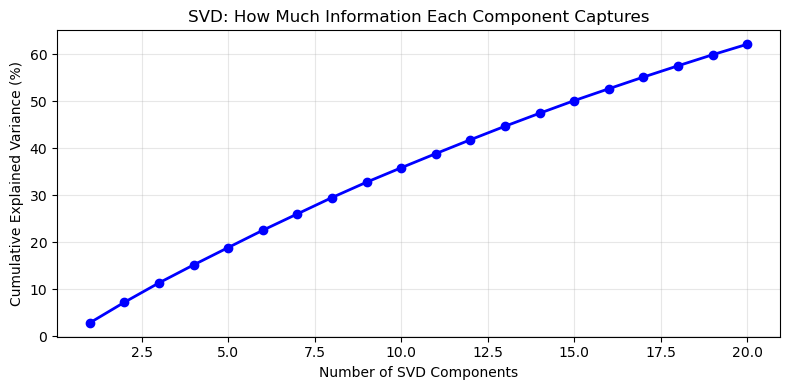

✅ SVD variance chart saved as svd_variance.png


In [17]:
# Visualise explained variance by SVD components
# Each SVD component captures a fraction of the total variance in the rating matrix.
# The cumulative explained variance curve tells us:
#   - How many components we need to capture 'most' of the signal.
#   - Whether 20 components is enough, or we should use more/fewer.
#
# A steep initial rise followed by a plateau is ideal — it means a small number
# of latent factors capture the bulk of the information.

plt.figure(figsize=(8, 4))
plt.plot(
    range(1, 21),
    np.cumsum(svd.explained_variance_ratio_) * 100,
    'bo-',           # Blue dots connected by lines
    linewidth=2
)
plt.xlabel('Number of SVD Components')
plt.ylabel('Cumulative Explained Variance (%)')
plt.title('SVD: How Much Information Each Component Captures')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('svd_variance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ SVD variance chart saved as svd_variance.png')


## 🔀 Step 6: Hybrid Recommender

**Idea:** Neither content-based nor collaborative filtering is perfect on its own:
- Content-based ignores what other users think.
- Collaborative filtering ignores movie content entirely.

A **hybrid system** blends both signals using a weighted score:

```
hybrid_score = alpha x content_score + (1 - alpha) x collaborative_score
```

- `alpha = 0.6` means we trust content similarity 60% and collaborative signals 40%.
- Tuning `alpha` lets you shift the balance based on which method performs better for your data.

In [18]:
def hybrid_recommend(user_id, liked_movie_title, n=5, alpha=0.6):
    """
    Hybrid recommender: blends content-based and collaborative filtering.

    How it works:
      1. Get content-based scores for movies similar to `liked_movie_title`.
      2. Get collaborative scores for movies the target `user_id` might enjoy.
      3. Find the overlap between the two candidate lists.
      4. Normalize each score to [0, 1] so they are on the same scale.
      5. Compute hybrid_score = alpha x content + (1-alpha) x collaborative.
      6. Return the top-N movies by hybrid score.

    Parameters
    ----------
    user_id           : int   Target user to personalise recommendations for.
    liked_movie_title : str   A movie the user liked (used for content signal).
    n                 : int   Number of recommendations (default 5).
    alpha             : float Weight for content-based score (default 0.6).
                              (1-alpha) is the weight for collaborative score.
    """
    print(f'Hybrid Recommendations for User {user_id}')
    print(f'Based on liking: "{liked_movie_title}"')
    print(f'Weights: Content={alpha:.0%}, Collaborative={1-alpha:.0%}\n')

    # Content-based candidates (top 20 similar to the liked movie) \
    content_recs = content_recommend(liked_movie_title, n=20)
    if content_recs is None:
        return
    content_recs = content_recs.rename(columns={'similarity': 'content_score'})

    # Collaborative candidates (top 20 for the user)
    collab_recs = collab_recommend(user_id, n=20)
    if collab_recs is None:
        return

    # Merge on title (inner join keeps only movies in BOTH lists)
    # If the overlap is empty, fall back to content-based recommendations only
    merged = content_recs.merge(collab_recs, on='title', how='inner')
    if merged.empty:
        print('No overlap found — falling back to content-based only:')
        print(content_recs.head(n).to_string(index=False))
        return

    # Normalise scores to [0, 1] before combining
    # Without normalisation, one score could dominate the other simply due to scale.
    merged['content_score']    = merged['content_score']    / merged['content_score'].max()
    merged['predicted_rating'] = merged['predicted_rating'] / 10.0   # Ratings are out of 10

    # Compute hybrid score
    merged['hybrid_score'] = (
        alpha * merged['content_score'] +
        (1 - alpha) * merged['predicted_rating']
    )
    merged = merged.sort_values('hybrid_score', ascending=False).head(n)

    print(merged[['title', 'genres_x', 'hybrid_score']].to_string(index=False))

In [19]:
# Test the hybrid recommender 
# User 1 likes The Dark Knight — expect dark action/crime/thriller movies
# that also align with what User 1's taste neighbours have enjoyed.
hybrid_recommend(1, 'The Dark Knight', n=5)

print()

# User 5 likes Toy Story — expect family/animation movies
# that also fit User 5's collaborative profile.
hybrid_recommend(5, 'Toy Story', n=5)

Hybrid Recommendations for User 1
Based on liking: "The Dark Knight"
Weights: Content=60%, Collaborative=40%

                   title                      genres_x  hybrid_score
               John Wick         action thriller crime      0.924000
           The Godfather          crime drama thriller      0.850184
                Die Hard        action thriller comedy      0.706690
The Silence of the Lambs thriller crime horror mystery      0.649345
              The Matrix        action sci-fi thriller      0.623757

Hybrid Recommendations for User 5
Based on liking: "Toy Story"
Weights: Content=60%, Collaborative=40%

        title                           genres_x  hybrid_score
        Shrek  animation comedy adventure family      0.959000
The Lion King             animation drama family      0.788800
Spirited Away animation fantasy adventure family      0.747333
         Coco       animation drama family music      0.662867
  The Martian      sci-fi adventure comedy drama      0.


## 📏 Evaluation

### Quantitative Metrics

| Metric | What It Measures | Our Result |
|--------|-----------------|------------|
| **RMSE** | Average squared prediction error for SVD (lower = better) | See SVD cell above |
| **MAE**  | Average absolute prediction error (more interpretable) | See SVD cell above |

### Qualitative Observations

- **Content-Based Filtering** correctly groups movies by genre family (e.g. animation films cluster together, sci-fi thrillers form another cluster). It works even with no rating history, but it cannot surface surprising cross-genre discoveries.

- **Collaborative Filtering** personalises recommendations based on user behaviour, capturing preferences that genre tags alone cannot express (e.g. a user who loves slow-burn dramas and dark comedies). However, it suffers from the **cold-start problem**: new users and new movies have no rating history to work with.

- **SVD** handles data sparsity better than plain collaborative filtering by learning latent factors. The cumulative explained variance chart shows how many components are needed to capture the bulk of the signal.

- **Hybrid System** balances the strengths of both approaches. The `alpha` hyperparameter controls the trade-off and can be tuned with cross-validation on a held-out set.

### Limitations

- The dataset is synthetic — in production you would need real rating data with richer metadata (cast, director, plot summaries, user demographics).
- Our collaborative step uses a simple mean rating from neighbours. More advanced approaches (e.g. Surprise SVD++, neural collaborative filtering) would improve accuracy.
- The hybrid merge uses an inner join — if the content and collaborative candidate lists have little overlap, recommendations fall back to content-based only.



## ✅ Conclusion

In this project we built a complete, end-to-end **Movie Recommendation System** covering four complementary techniques:

| System | Technique | Key Metric |
|--------|-----------|------------|
| Content-Based | TF-IDF + Cosine Similarity | Similarity Score |
| Collaborative | User-User Similarity | Coverage and Personalisation |
| Matrix Factorisation | Truncated SVD | RMSE / MAE |
| Hybrid | Weighted Score (alpha) | Combined Score |

**Key takeaways:**
- No single method wins in all situations. Real-world platforms (Netflix, Spotify, Amazon) always use hybrid or ensemble approaches.
- Data sparsity is the central challenge of recommendation systems. SVD and collaborative filtering are specifically designed to address it.
- The `alpha` weight in the hybrid system is a powerful lever — tune it based on how much content metadata vs. user behaviour data you have.

**Possible next steps:**
- Swap synthetic data for a real dataset (e.g. MovieLens 100K from GroupLens).
- Replace TF-IDF with richer embeddings (e.g. word2vec on plot summaries).
- Implement Surprise SVD++ or a Neural Collaborative Filtering model.
- Add a Precision@K / Recall@K evaluation loop.
- Deploy as a Streamlit web app.
